In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.optimize import lsq_linear
import matplotlib.ticker as ticker
sns.set_theme()
sns.set_style('whitegrid')

In [2]:
plt.rcParams['font.size'] = 7
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['axes.labelsize'] = 7
plt.rcParams['axes.titlesize'] = 7
plt.rcParams['ytick.major.pad'] = -2
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 5

## Figure 2

In [3]:
def error(true, pred):
    return np.mean(np.abs(true-pred)) / np.mean(true)

renames = {
    'normal':'Basic',
    'high_coverage':'High\ncoverage',
    'low_variance':'Low expression\nvariance'
}

In [4]:
configs = ['normal', 'low_variance', 'high_coverage']
func_error = error
directory_true = 'simulations/paper_sim'
lines = []
directory_inferred_all = 'simulations/paper'

dirs = ['Results_numpy_only_tum', 'Results_numpy', 'Results_numpy_best']
names = ['Tumoroscope', 'TumoroscopeGE', 'TumoroscopeGE 5 chains']    
 

for ver in configs:
    for i in range(1,21):
        for results_dir, name in zip(dirs, names):
            directory_inferred = directory_inferred_all + '/' + results_dir
            sample = pickle.load(open(f'{directory_true}/{i}/sample_{ver}', 'rb'))
            B = sample.B

            H = sample.H
            H_pred = np.load(f'{directory_inferred}/inferred_H_{ver}_{i}.npy')

            N = sample.n
            N_pred = np.load(f'{directory_inferred}/inferred_N_{ver}_{i}.npy')

            phi = sample.phi
            phi_pred = np.load(f'{directory_inferred}/inferred_phi_{ver}_{i}.npy')
            try:
                B_pred = np.load(f'{directory_inferred}/inferred_B_{ver}_{i}.npy')
            except:
                Y = sample.Y
                N_matrix = N_pred * np.eye(len(N_pred))
                X = np.matmul(N_matrix, H_pred)

                B_pred = np.zeros(B.shape)
                for g in range(Y.shape[1]):
                    if sum(Y[:,g]) > 0:
                        B_pred[:,g] = lsq_linear(X, Y[:,g], bounds=(0, np.inf)).x

            b = func_error(B, B_pred)
            h = func_error(H, H_pred)
            n = func_error(N, N_pred)
            phi = func_error(phi, phi_pred)
            lines.append([ver, name, b, h, n, phi])
            
results = pd.DataFrame(lines, columns=['Name', 'Model', 'B_err', 'H_err', 'N_err', 'phi_err'])

FileNotFoundError: [Errno 2] No such file or directory: 'simulations/paper_sim/1/sample_normal'

NameError: name 'results' is not defined

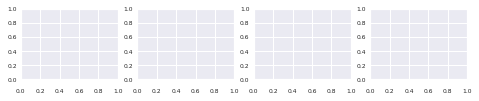

In [5]:
plt.rcParams['ytick.major.pad'] = -2
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
fig, axes = plt.subplots(1, 4, figsize=(8,1.3))
palette = [(1.0, 1.0, 0.7),
           (0.5, 0.8, 0.7),
           (0, 0.5, 0.5)]
letters = ['a', 'b', 'c', 'd']
for i, col in enumerate(results.columns[2:]):
    sns.set_context(rc={"grid.linewidth": 0.5}) 
    box = sns.boxplot(data=results, x='Name', y=col, hue='Model', palette=palette, linewidth=0.5, 
                      ax=axes[i], fliersize=1.5)   
    plt.setp(box.artists, edgecolor = 'k')
    plt.setp(box.lines, color = 'k')
    axes[i].set_ylim(0, max(results[col])*1.1)
    var = col.split('_')[0]
    if var == 'phi':
        var = r'$\Phi$'
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].set_ylabel('Error')
    else:
        axes[i].set_ylabel('')
    axes[i].set_title(f'Inference of {var}')
    axes[i].text(-0.2, 1.25, letters[i], transform=axes[i].transAxes, fontsize=7, va='top')
    labels = axes[i].get_xticklabels()
    plt.setp(labels, rotation=45, horizontalalignment='right')
    if i < 3:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(loc='center left', bbox_to_anchor=(-3.3, -0.9), ncol=3, frameon=False)
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.4))
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[2].yaxis.set_major_locator(ticker.MultipleLocator(0.05))
axes[3].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.subplots_adjust(wspace=0.4)
plt.savefig('plots_paper/simulations_boxplots.png', dpi=350, bbox_inches='tight')
plt.savefig('plots_paper/simulations_boxplots.eps', dpi=350, bbox_inches='tight')
# plt.show()

## Real data results

In [6]:
n = 10
logliks = pd.read_csv('Results_paper_GE_logliks.txt', header=None).values.flatten()

best_Hs = []
best_ids = []
for k in range(1, 100, n):
    Hs = []
    for i in range(k, k+n):
        H = np.load(f'H_my_paper/Results_paper_GE_{i}_h.npy')
        Hs.append(H)
    corrs = np.corrcoef([H.flatten() for H in Hs])
    
    ll_max = min(logliks)
    for i, line in enumerate(corrs):
        corrs_i = list(line[:i]) + list(line[i+1:])
        if max(corrs_i) > 0.9:   # if it has at least one similar chain, check for best likelihood
            if logliks[k+i-1] > ll_max:
                ll_max, best_i = logliks[k+i-1], i
    corrs_i = corrs[best_i]
    print(np.where(corrs_i > 0.9)[0], ll_max)
    best_Hs += list(np.array(Hs)[np.where(corrs_i > 0.9)[0]])
    best_ids += list(np.where(corrs_i > 0.9)[0] + k)

[3 4 9] -42066.66556225109
[1 3] -42291.622904589305
[0 3 9] -42097.36563445455
[1 3 6 9] -42050.19758546424
[0 1 6 9] -42110.56203227574
[5 9] -42181.537370377206
[0 3] -42142.393181764535
[2 5] -41995.671903565926
[2 5] -42162.97237080257
[1 2] -42165.77643524717


In [7]:
Ns = []
for i in best_ids:
    N = np.load(f'N_my_paper/Results_paper_GE_{i}_n.npy')
    Ns.append(N)
N_pred = np.array(Ns).mean(axis=0)

Bs = []
for i in best_ids:
    B = np.load(f'B_my_paper/Results_paper_GE_{i}_b.npy')
    Bs.append(B)
B_pred = np.array(Bs).mean(axis=0)

H_pred = np.array(best_Hs).mean(axis=0)  

In [8]:
spots = pd.read_csv('Results_paper_GE_3/spots_order.txt', header=None).loc[:,0]
sections = ['P1.2', 'P2.4', 'P3.3']

H_ext = pd.read_csv('../Results_realdata_prostate_15jan_3clone/h_extended.txt', sep=' ')
H_ext.index = H_ext.barcode
H_ext = H_ext.loc[spots]
xs = H_ext.coordinates.str.split('x').str[0].astype('int').values
ys = H_ext.coordinates.str.split('x').str[1].astype('int').values

## Figure 3

In [9]:
genes = pd.read_csv('Results_paper_GE_3/genes_order.txt', header=None).loc[:,0].str.split().str[0].values
B_df = pd.DataFrame(B.T, index=genes, columns=['Clone 1', 'Clone 2', 'Clone 3', 'Clone 4'])
B_df

,Clone 1,Clone 2,Clone 3,Clone 4
FUCA1,3.534097e-28,1.159777e-16,7.252157e-18,0.063088
RNF126,3.718085e-02,2.708954e-02,2.344623e-01,0.054660
CYB5A,4.614257e-20,2.235289e-18,2.237692e-19,0.065542
CAMKK2,1.278390e-02,1.276447e-01,4.073682e-44,0.104568
CUEDC1,4.109125e-21,9.138577e-02,4.149965e-33,0.073995
...,...,...,...,...
SPON2,4.940656e-324,1.427817e+00,2.854140e-01,2.471462
KLK2,1.504182e+00,3.578947e+00,2.695583e+00,4.931546
ACTB,1.223541e+01,4.886111e+00,1.117478e+00,5.011480
MSMB,7.395571e-32,4.733165e-30,5.361600e-01,10.602826


In [10]:
import os

Bs = []
Bs_all = []
for d in os.listdir('B_samples/'):
    dir_in = 'B_samples/' + d
    i = 5000
    bs = []
    while os.path.exists(f'{dir_in}/B_{i}.npy'):
        B = np.load(f'{dir_in}/B_{i}.npy')
        bs.append(B)
        Bs_all.append(B)
        i += 1000
    Bs.append(bs)
Bs = np.array(Bs)
Bs_all = np.array(Bs_all)

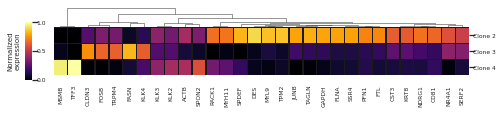

In [11]:
B_df = B_df[['Clone 2', 'Clone 3', 'Clone 4']]
df = B_df.loc[B_df.var(axis=1).sort_values(ascending=False).index][:30]
df = df.divide(df.sum(axis=1), axis=0)
df = df.transpose()

hm = sns.clustermap(df, cbar=True, figsize=(7,1.6), yticklabels=True, row_cluster=False,  # 
                    col_cluster=True, cmap='inferno', vmax=1,
                    linewidths=0.3, linecolor='k',
                    cbar_kws={'label':'Normalized\nexpression'}, 
                    cbar_pos=(0.05, 0.3, 0.015, 0.5),
                    dendrogram_ratio=(0.1, 0.3)
                    )
hm.fig.axes[-1].yaxis.set_label_position('left')
hm.fig.axes[-1].yaxis.set_ticks([0, 0.5, 1])

plt.savefig('plots_paper/B1.png', dpi=350)

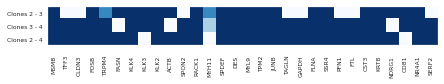

In [21]:
from scipy.stats import ranksums

test_func = ranksums

genes_new_order = []

gene_ids = []
for g in range(30):
    gene = hm.fig.axes[2].get_xticklabels()[g].get_text()
    genes_new_order.append(gene)
    gene_ids.append(np.where(genes==gene)[0][0])

p_vals = np.zeros((3, 30))
for i, g in enumerate(gene_ids):
    p_vals[0, i] = test_func(x=Bs_all[:,1,g], y=Bs_all[:,2,g]).pvalue
    p_vals[1, i] = test_func(x=Bs_all[:,2,g], y=Bs_all[:,3,g]).pvalue
    p_vals[2, i] = test_func(x=Bs_all[:,1,g], y=Bs_all[:,3,g]).pvalue
    
p_vals_corr = p_vals * 3 * 30  # bonferroni correction for nr of comparisons
p_vals_colors = np.zeros((3, 30))
p_vals_colors[p_vals_corr < 0.05] = 1
p_vals_colors[p_vals_corr < 0.01] = 2
p_vals_colors[p_vals_corr < 0.001] = 3

plt.figure(figsize=(7,1.5))
plt.imshow(p_vals_colors, cmap='Blues')
plt.xticks(range(30), genes_new_order, rotation=90)
plt.yticks(range(3), ['Clones 2 - 3', 'Clones 3 - 4', 'Clones 2 - 4'])
plt.grid()
plt.savefig('plots_paper/B_pval.png', dpi=350, bbox_inches='tight')


## Figure 4

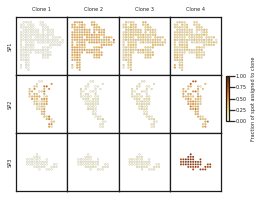

In [10]:
section_names = {'P3.3':'SP1', 'P2.4':'SP2', 'P1.2':'SP3'}

plt.rcParams['font.size'] = 5
plt.rcParams['legend.fontsize'] = 5
plt.rcParams['axes.labelsize'] = 5
plt.rcParams['axes.titlesize'] = 5
plt.rcParams['xtick.labelsize'] = 5
plt.rcParams['ytick.labelsize'] = 5

plt.rcParams['ytick.major.pad'] = 1
H = np.array(best_Hs).mean(axis=0)  
fig, axes = plt.subplots(3, 4, figsize=(3.386,2.7))
for i, section in enumerate(['P3.3', 'P2.4', 'P1.2']):
    axes[i,0].set_ylabel(section_names[section])
    for j in range(4):
        axes[0,j].set_title('Clone ' + str(j+1))
        s1 = spots.str.startswith(section)
        sc = axes[i,j].scatter(xs[s1], ys[s1], c=H[s1, j], vmin=0, vmax=1, s=3, cmap='YlOrBr', 
                               edgecolors='k', linewidth=0.1)
        axes[i,j].grid()
        axes[i,j].set_xticks([])
        axes[i,j].set_yticks([])
        w = xs[s1].max() - xs[s1].min()
        h = ys[s1].max() - ys[s1].min()
        axes[i,j].set_xlim(xs[s1].min()-(21-w)/2, xs[s1].max()+(21-w)/2)
        axes[i,j].set_ylim(ys[s1].min()-(23-h)/2, ys[s1].max()+(23-h)/2)

plt.tight_layout()
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.385, 0.01, 0.235])
cb = fig.colorbar(sc, label='Fraction of spot assigned to clone', cax=cbar_ax)
cb.outline.set_edgecolor('k')

plt.subplots_adjust(wspace=0, hspace=0)

for ax1 in axes:
    for ax in ax1:
        for spine in ax.spines.values():
            spine.set_edgecolor('k')

plt.savefig('plots_paper/real_H.eps', dpi=350)
# plt.savefig('plots_paper/real_H.png', dpi=350)
# plt.savefig('plots_paper/real_H.tif', dpi=350)
plt.show()

## Figure 5

In [ ]:
t = pickle.load(open('Results1000_300k_iters/inferred_vars_all', 'rb'))
sections = ['P1.2', 'P2.4', 'P3.3']
means = [t.Y[spots.str.startswith(section)].mean() for section in sections]
means = np.array(means)
scaling_factors = np.mean(means) / means
Y_scaled = np.zeros(t.Y.shape) + t.Y
for section, s in zip(sections, scaling_factors):
    Y_scaled[spots.str.startswith(section)] *= s
    
scaling_factors_array = np.zeros(t.Y.shape[0])
for section, scaling_factor  in zip(sections, scaling_factors):
    scaling_factors_array[spots.str.startswith(section)] = scaling_factor
scaling_factors_array = scaling_factors_array.reshape(-1,1)
scaling_factors_array = 1 / scaling_factors_array

In [ ]:
H = np.load(f'numpy_all/Results1000_t_only_tum_est_rp_8_h.npy')
N = np.load(f'numpy_all/Results1000_t_only_tum_est_rp_8_n.npy')
N = N * np.eye(len(N))
X = np.matmul(N,H)

B = np.zeros((4, 1000))
for g in range(1000):
    if sum(Y_scaled[:,g]) > 0:
        B[:,g] = lsq_linear(X, Y_scaled[:,g], bounds=(0, np.inf)).x
Y_pred1 = np.matmul(X * scaling_factors_array, B)

N = N_pred * np.eye(len(N_pred))
X = np.matmul(N, H_pred)
Y_pred2 = np.matmul(X * scaling_factors_array, B_pred)

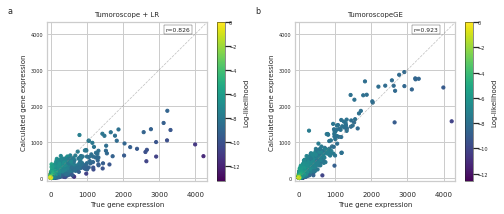

In [11]:
Y_preds = [Y_pred1, Y_pred2]

fig, axes = plt.subplots(1, 2, figsize=(7,3))
letters = ['a', 'b']

for i, Y_pred in enumerate(Y_preds):
    r = np.matmul(Y_pred, np.diag(t.p_y / (1 - t.p_y)))
    ll = scipy.stats.nbinom.logpmf(t.Y, r, p=t.p_y)
    sc = axes[i].scatter(t.Y[:, ::-1], Y_pred[:, ::-1], s=10, c=ll[:, ::-1], cmap='viridis', vmin=ll.min()-1, vmax=0)
    lims = axes[i].get_xlim()
    axes[i].plot(lims, lims, '--', color='gray', alpha=0.5, linewidth=0.7)
    axes[i].set_xlabel('True gene expression')
    axes[i].set_ylabel('Calculated gene expression')
    axes[i].set_xlim(-100, np.max(t.Y)+100)
    axes[i].set_ylim(-100, np.max(t.Y)+100)
    axes[i].xaxis.set_major_locator(ticker.MultipleLocator(1000))
    axes[i].yaxis.set_major_locator(ticker.MultipleLocator(1000))
    cb = plt.colorbar(sc, label='Log-likelihood', ax=axes[i])
    cb.outline.set_edgecolor('k')
    cb.outline.set_linewidth(0.5)
    corr = np.round(np.corrcoef(t.Y.flatten(), Y_pred.flatten())[0,1], 3)
    axes[i].text(0.74, 0.97, 'r='+str(corr), transform=axes[i].transAxes, fontsize=6,
                 verticalalignment='top', 
                 bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', lw=0.3))
    axes[i].text(-0.25, 1.1, letters[i], transform=axes[i].transAxes, fontsize=8, va='top')

axes[0].set_title('Tumoroscope + LR')
axes[1].set_title('TumoroscopeGE')

plt.subplots_adjust(wspace=0.40)
plt.tight_layout()
# plt.savefig('plots_paper/Y_validation.png', dpi=400)